# 1. RNN TIME SERIES FORECASTING

In [ ]:
# import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
print('Tensorflow version: ', tf.__version__)

Tensorflow version:  2.17.1


In [ ]:
# to make this notebook's output stable across runs
np.random.seed(43)
tf.random.set_seed(43)

# To plot pretty figures
# matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [ ]:
# Function to generate a time series
def generate_time_series(batch_size, steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, steps) - 0.5)   # + noise
    return series[..., np.newaxis].astype(np.float32)

In [ ]:
# Create a training, valditation and test set with 'extra_steps' additional steps

n_steps = 50
extra_steps = 30
series = generate_time_series(10000, n_steps + extra_steps)
X_train, Y_train = series[:7000, :n_steps], series[:7000, -extra_steps:, 0]
X_valid, Y_valid = series[7000:9000, :n_steps], series[7000:9000, -extra_steps:, 0]
X_test, Y_test = series[9000:, :n_steps], series[9000:, -extra_steps:, 0]

print('Shapes:')
print('Generated time series : ', series.shape)
print('X_train : ', X_train.shape)
print('Y_train : ', Y_train.shape)
print('X_valid : ', X_valid.shape)
print('Y_valid : ', Y_valid.shape)
print('X_test : ', X_test.shape)
print('Y_test : ', Y_test.shape)

Shapes:
Generated time series :  (10000, 80, 1)
X_train :  (7000, 50, 1)
Y_train :  (7000, 30)
X_valid :  (2000, 50, 1)
Y_valid :  (2000, 30)
X_test :  (1000, 50, 1)
Y_test :  (1000, 30)


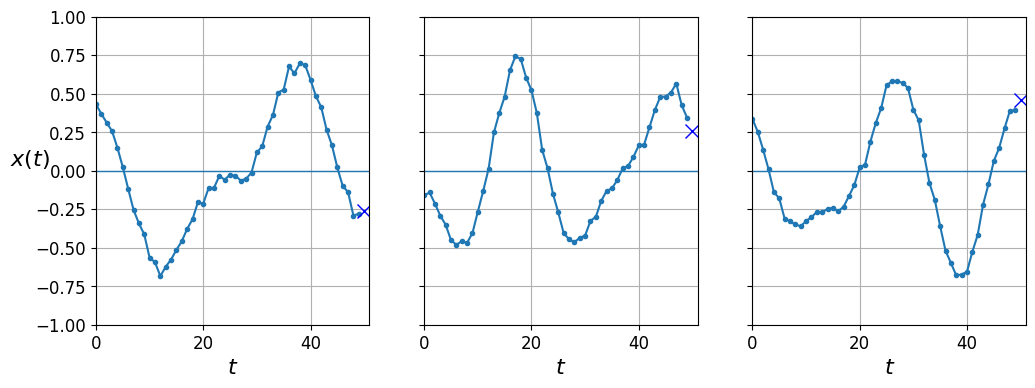

In [ ]:
# Define plots for time series
def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x(t)$"):
    plt.plot(series, ".-")
    if y is not None:
        plt.plot(n_steps, y, "bx", markersize=10)
    if y_pred is not None:
        plt.plot(n_steps, y_pred, "ro")
    plt.grid(True)
    if x_label:
        plt.xlabel(x_label, fontsize=16)
    if y_label:
        plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.hlines(0, 0, 100, linewidth=1)
    plt.axis([0, n_steps + 1, -1, 1])

# Define plot multiple forecasts
def plot_multiple_forecasts(X, Y, Y_pred):
    n_steps = X.shape[1]
    ahead = Y.shape[1]
    plot_series(X[0, :, 0])
    plt.plot(np.arange(n_steps, n_steps + ahead), Y[0, :, 0], "ro-", label="Actual")
    plt.plot(np.arange(n_steps, n_steps + ahead), Y_pred[0, :, 0], "bx-", label="Forecast", markersize=10)
    plt.axis([0, n_steps + ahead, -1, 1])
    plt.legend(fontsize=14)

#plot first 3 timeseries from validation set
fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))
for col in range(3):
    plt.sca(axes[col])
    plot_series(X_valid[col, :, 0], Y_valid[col, 0],
                y_label=("$x(t)$" if col==0 else None))
plt.show()

In [ ]:
# Create a model: 3-layer RNN
# Try to build a model that can predict 'extra_steps' = 30 at once, using a sequence-to-vector RNN
np.random.seed(42)
tf.random.set_seed(42)

model_rnn = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=[None, 1]),
    tf.keras.layers.SimpleRNN(60, return_sequences=True),
    tf.keras.layers.SimpleRNN(60),
    tf.keras.layers.Dense(extra_steps)
])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, None, 60)            │           3,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 60)                  │           7,260 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 30)                  │           1,830 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,810 (50.04 KB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 0 (0.00 B)

None


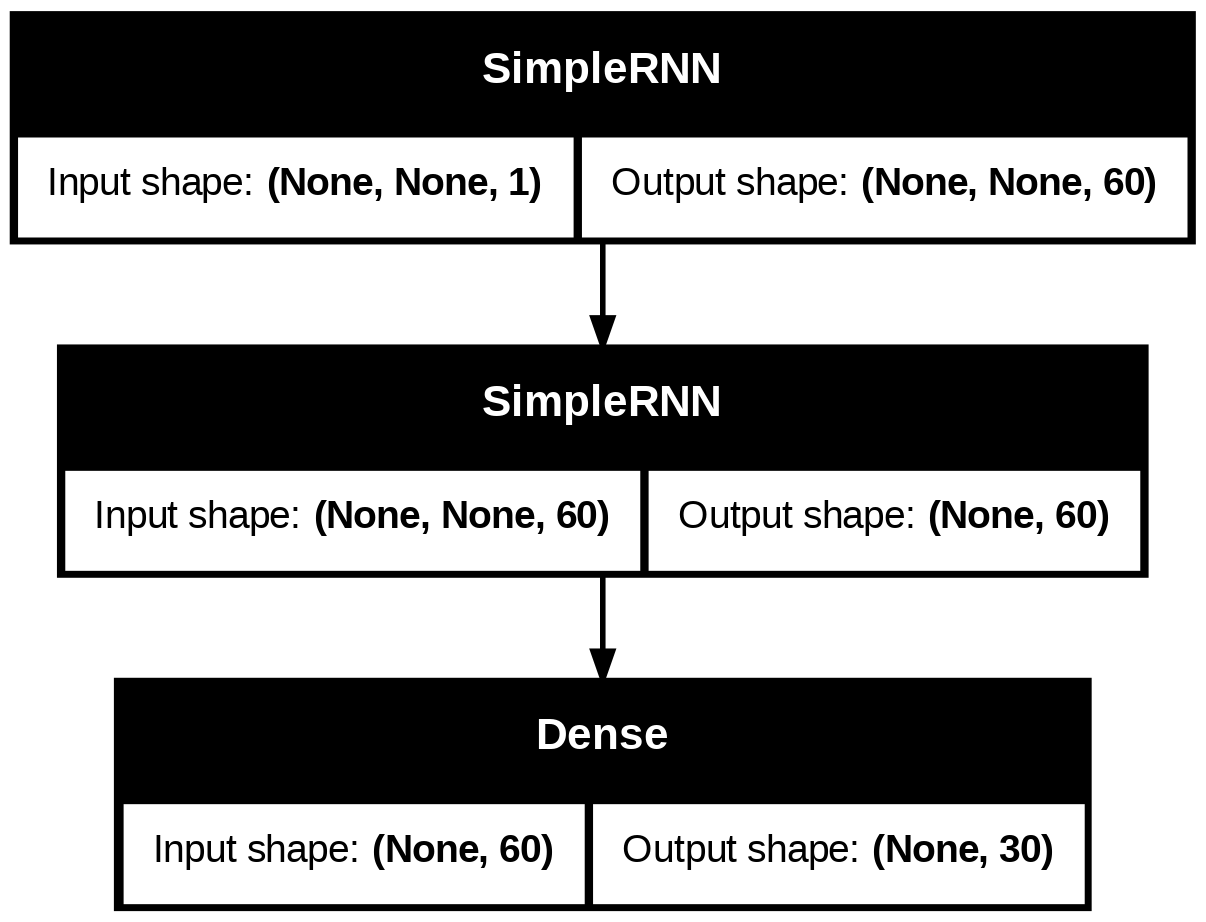

In [ ]:
# print model summary
print (model_rnn.summary())

keras.utils.plot_model(model_rnn, "my_rnn_model.png", show_shapes=True)

In [ ]:
# Specify the loss function
model_rnn.compile(loss="mse", optimizer="adam")

In [ ]:
# Train the model with 20 epochs
history = model_rnn.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0924 - val_loss: 0.0315
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0308 - val_loss: 0.0244
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0261 - val_loss: 0.0235
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0231 - val_loss: 0.0213
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0220 - val_loss: 0.0198
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0214 - val_loss: 0.0198
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0211 - val_loss: 0.0202
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0205 - val_loss: 0.0197
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0201 - val_loss: 0.0195
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0201 - val_loss: 0.0197
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0203 - val_loss: 0.0181
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Evaluate model
model_rnn.evaluate(X_test, Y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0154


0.015636121854186058

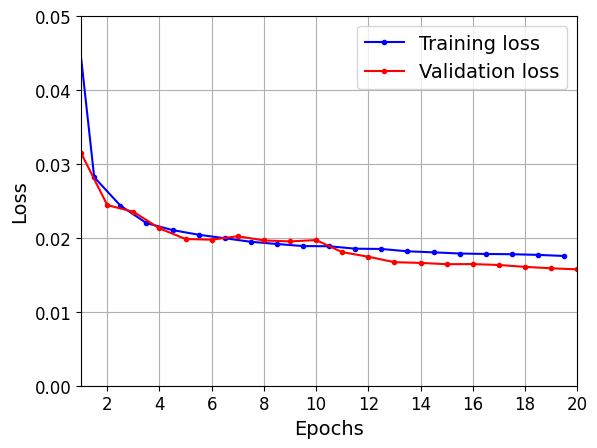

In [ ]:
# Define learning curves
def plot_learning_curves(loss, val_loss):
    plt.plot(np.arange(len(loss)) + 0.5, loss, "b.-", label="Training loss")
    plt.plot(np.arange(len(val_loss)) + 1, val_loss, "r.-", label="Validation loss")
    plt.gca().xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    plt.axis([1, 20, 0, 0.05])
    plt.legend(fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)

# Plot learning curve
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

In [ ]:
# Predict output value

X_new = X_test
Y_new = Y_test[..., np.newaxis]
Y_pred = model_rnn.predict(X_new)[..., np.newaxis]

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


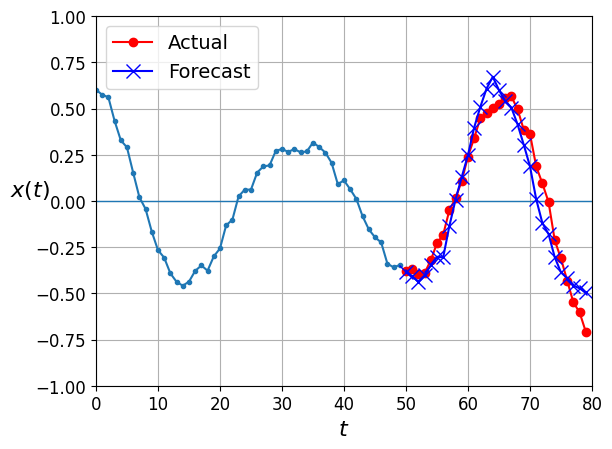

In [ ]:
# Plot time serie including prediction (first time serie from the test set)
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

# 2. LSTM TIME SERIES FORECASTING

In [ ]:
# check runtime before running neural networks
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print("GPU device is not selected. CNNs and LSTMs can be very slow without a GPU.")
    print("Go to Runtime > Change runtime type and select a GPU hardware accelerator.")
else:
    print("GPU device is running. CNNs and LSTMs will run much faster on a GPU device.")

GPU device is running. CNNs and LSTMs will run much faster on a GPU device.


In [ ]:
# import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
print('Tensorflow version: ', tf.__version__)

Tensorflow version:  2.17.1


In [ ]:
# to make this notebook's output stable across runs
np.random.seed(43)
tf.random.set_seed(43)

# To plot pretty figures
# matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [ ]:
# Function to generate a time series
def generate_time_series(batch_size, steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, steps) - 0.5)   # + noise
    return series[..., np.newaxis].astype(np.float32)

In [ ]:
# Create a training, valditation and test set with 'extra_steps' additional steps
np.random.seed(42)

n_steps = 50
extra_steps = 30
series = generate_time_series(10000, n_steps + extra_steps)
X_train, Y_train = series[:7000, :n_steps], series[:7000, -extra_steps:, 0]
X_valid, Y_valid = series[7000:9000, :n_steps], series[7000:9000, -extra_steps:, 0]
X_test, Y_test = series[9000:, :n_steps], series[9000:, -extra_steps:, 0]

print('Shapes:')
print('Generated time series : ', series.shape)
print('X_train : ', X_train.shape)
print('Y_train : ', Y_train.shape)
print('X_valid : ', X_valid.shape)
print('Y_valid : ', Y_valid.shape)
print('X_test : ', X_test.shape)
print('Y_test : ', Y_test.shape)

Shapes:
Generated time series :  (10000, 80, 1)
X_train :  (7000, 50, 1)
Y_train :  (7000, 30)
X_valid :  (2000, 50, 1)
Y_valid :  (2000, 30)
X_test :  (1000, 50, 1)
Y_test :  (1000, 30)


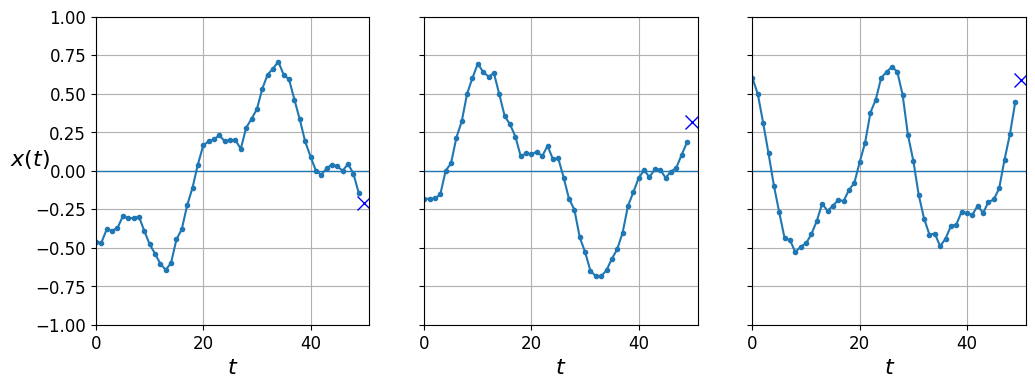

In [ ]:
# Define plots for time series
def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x(t)$"):
    plt.plot(series, ".-")
    if y is not None:
        plt.plot(n_steps, y, "bx", markersize=10)
    if y_pred is not None:
        plt.plot(n_steps, y_pred, "ro")
    plt.grid(True)
    if x_label:
        plt.xlabel(x_label, fontsize=16)
    if y_label:
        plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.hlines(0, 0, 100, linewidth=1)
    plt.axis([0, n_steps + 1, -1, 1])

# Define plot multiple forecasts
def plot_multiple_forecasts(X, Y, Y_pred):
    n_steps = X.shape[1]
    ahead = Y.shape[1]
    plot_series(X[0, :, 0])
    plt.plot(np.arange(n_steps, n_steps + ahead), Y[0, :, 0], "ro-", label="Actual")
    plt.plot(np.arange(n_steps, n_steps + ahead), Y_pred[0, :, 0], "bx-", label="Forecast", markersize=10)
    plt.axis([0, n_steps + ahead, -1, 1])
    plt.legend(fontsize=14)

#plot first 3 timeseries from validation set
fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))
for col in range(3):
    plt.sca(axes[col])
    plot_series(X_valid[col, :, 0], Y_valid[col, 0],
                y_label=("$x(t)$" if col==0 else None))
plt.show()

In [ ]:
# Create a model: 3-layer LSTM
# Try to build a model that can predict 'extra_steps' = 30 at once at final step

np.random.seed(42)
tf.random.set_seed(42)

model_lstm = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=[None, 1]),
    tf.keras.layers.LSTM(60, return_sequences=True),
    tf.keras.layers.LSTM(60),
    tf.keras.layers.Dense(extra_steps)
])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, None, 60)            │          14,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 60)                  │          29,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30)                  │           1,830 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 45,750 (178.71 KB)

 Trainable params: 45,750 (178.71 KB)

 Non-trainable params: 0 (0.00 B)

None


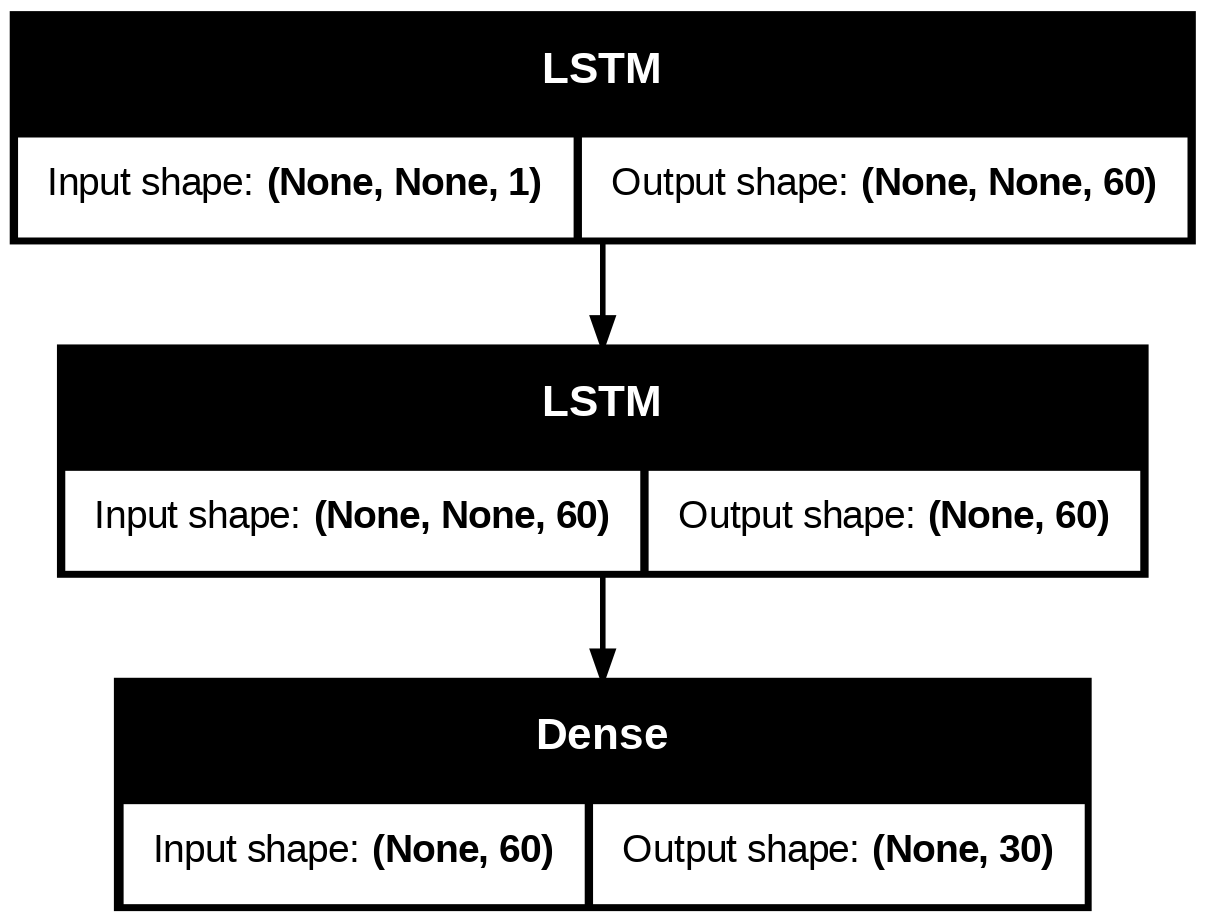

In [ ]:
# print model summary
print (model_lstm.summary())

keras.utils.plot_model(model_lstm, "my_lstm_model.png", show_shapes=True)

In [ ]:
# Specify the loss function
model_lstm.compile(loss="mse", optimizer="adam")

In [ ]:
# Train the model with 20 epochs
history = model_lstm.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0882 - val_loss: 0.0315
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0303 - val_loss: 0.0259
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0255 - val_loss: 0.0230
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0233 - val_loss: 0.0217
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0219 - val_loss: 0.0208
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0207 - val_loss: 0.0197
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0196 - val_loss: 0.0182
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0185 - val_loss: 0.0169
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0176 - val_loss: 0.0163
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0171 - val_loss: 0.0158
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0166 - val_loss: 0.0154
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/s

In [ ]:
# Evaluate model
model_lstm.evaluate(X_test, Y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0073


0.007152542006224394

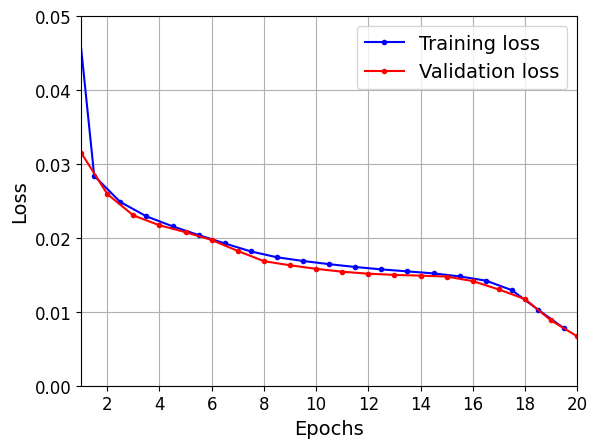

In [ ]:
# Define learning curves
def plot_learning_curves(loss, val_loss):
    plt.plot(np.arange(len(loss)) + 0.5, loss, "b.-", label="Training loss")
    plt.plot(np.arange(len(val_loss)) + 1, val_loss, "r.-", label="Validation loss")
    plt.gca().xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    plt.axis([1, 20, 0, 0.05])
    plt.legend(fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)

# Plot learning curve
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

In [ ]:
# Predict output value

X_new = X_test
Y_new = Y_test[..., np.newaxis]
Y_pred = model_lstm.predict(X_new)[..., np.newaxis]

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


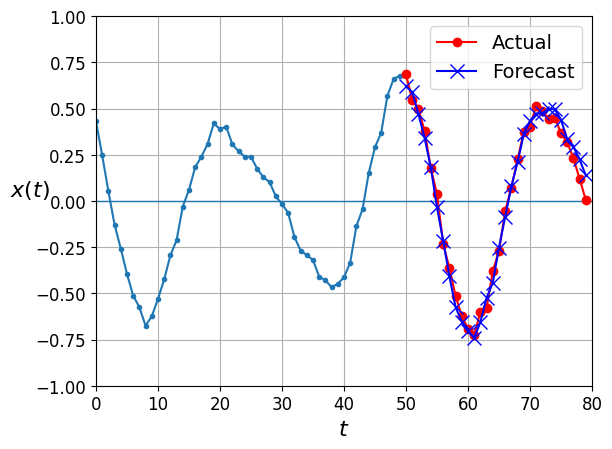

In [ ]:
# Plot time serie including prediction
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

# 3. ALTERNATIVE LSTM TIME SERIES FORECASTING

Now let's create an LSTM that predicts the next 30 steps at each time step. That is, instead of just forecasting time steps 50 to 79 based on time steps 0 to 49, it will forecast time steps 1 to 30 at time step 0, then time steps 2 to 31 at time step 1, and so on, and finally it will forecast time steps 50 to 79 at the last time step. Notice that the model is causal: when it makes predictions at any time step, it can only see past time steps.

In [ ]:
np.random.seed(42)

n_steps = 50
extra_steps = 30
series = generate_time_series(10000, n_steps + extra_steps)
X_train = series[:7000, :n_steps]
X_valid = series[7000:9000, :n_steps]
X_test = series[9000:, :n_steps]
Y = np.empty((10000, n_steps, extra_steps))
for step_ahead in range(1, extra_steps + 1):
    Y[..., step_ahead - 1] = series[..., step_ahead:step_ahead + n_steps, 0]
Y_train = Y[:7000]
Y_valid = Y[7000:9000]
Y_test = Y[9000:]

In [ ]:
X_train.shape, Y_train.shape

((7000, 50, 1), (7000, 50, 30))

In [ ]:
# Create a LSTM model for predicting 30 values at each time step
np.random.seed(42)
tf.random.set_seed(42)

model_lstm_2 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=[None, 1]),
    tf.keras.layers.LSTM(60, return_sequences=True),
    tf.keras.layers.LSTM(60, return_sequences=True),
    tf.keras.layers.TimeDistributed(keras.layers.Dense(extra_steps))
])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, None, 60)            │          14,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 60)                  │          29,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30)                  │           1,830 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 137,252 (536.14 KB)

 Trainable params: 45,750 (178.71 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 91,502 (357.43 KB)

None


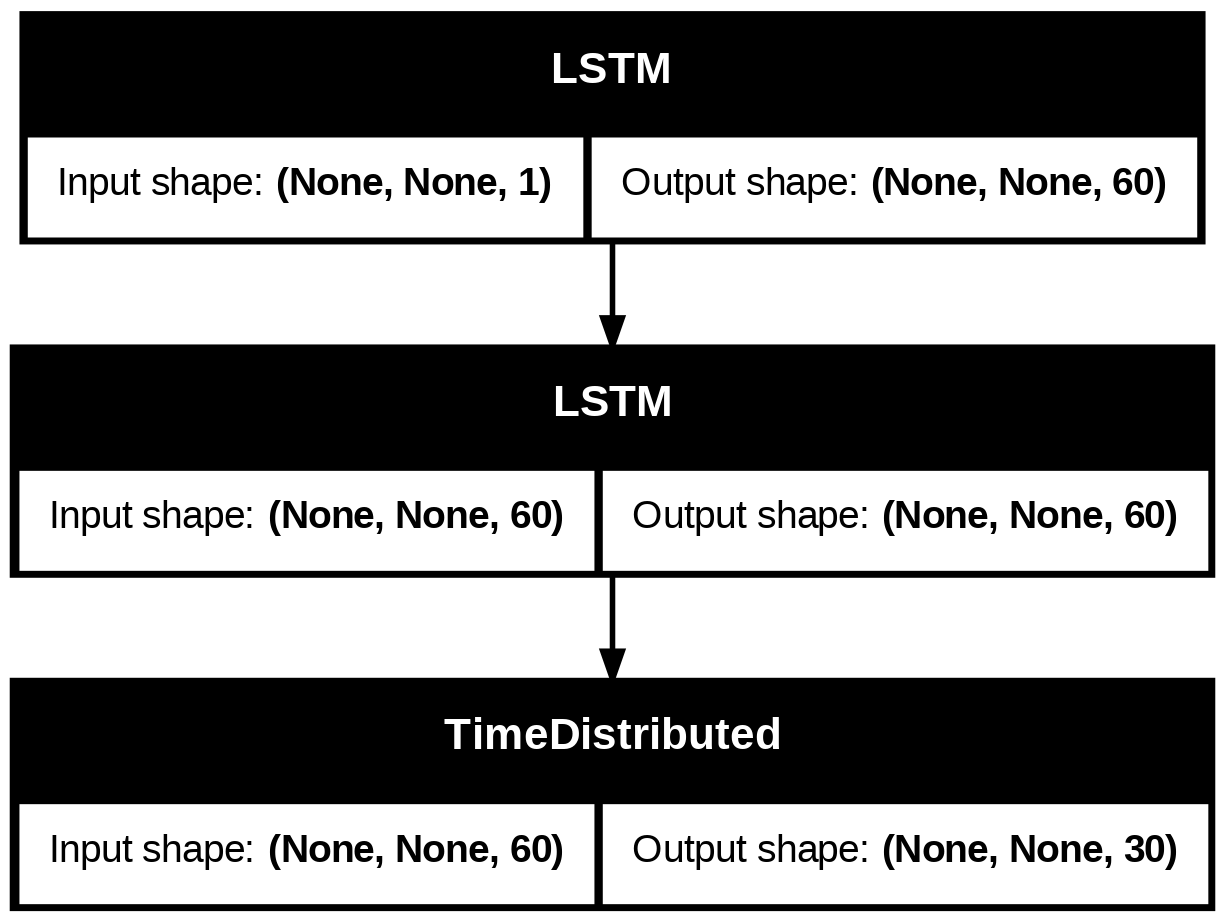

In [ ]:
# print model summary
print (model_lstm.summary())

keras.utils.plot_model(model_lstm_2, "my_lstm_model.png", show_shapes=True)

In [ ]:
# Specify the loss function
def last_time_step_mse(Y_true, Y_pred):
    return tf.reduce_mean(tf.square(Y_true[:, -1] - Y_pred[:, -1]))

model_lstm_2.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])

In [ ]:
# Train the model with 20 epochs
history = model_lstm_2.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - last_time_step_mse: 0.0915 - loss: 0.1036 - val_last_time_step_mse: 0.0311 - val_loss: 0.0652
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - last_time_step_mse: 0.0309 - loss: 0.0628 - val_last_time_step_mse: 0.0237 - val_loss: 0.0564
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - last_time_step_mse: 0.0248 - loss: 0.0557 - val_last_time_step_mse: 0.0212 - val_loss: 0.0524
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - last_time_step_mse: 0.0226 - loss: 0.0522 - val_last_time_step_mse: 0.0200 - val_loss: 0.0501
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - last_time_step_mse: 0.0215 - loss: 0.0502 - val_last_time_step_mse: 0.0195 - val_loss: 0.0486
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - last_time_step_mse: 0.0206 - loss: 0.0486 - val_last_time_step_mse: 0.0191 - val_loss: 0.0474
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - last_time_step_mse: 0.0199 - loss: 0.0473 - val_las

In [ ]:
# Evaluate model
model_lstm_2.evaluate(X_test, Y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - last_time_step_mse: 0.0050 - loss: 0.0303


[0.030646201223134995, 0.004958154167979956]

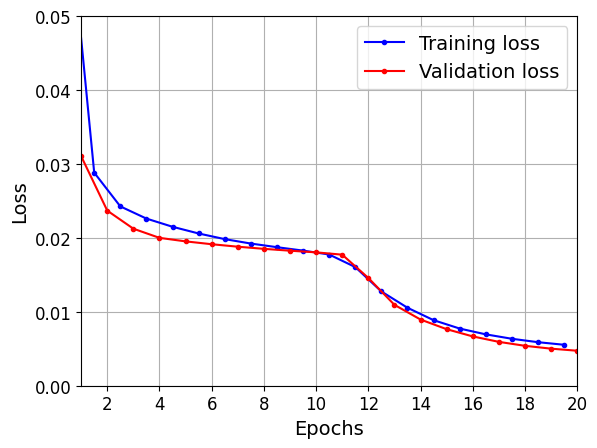

In [ ]:
# Plot learning curve
#plot_learning_curves(history.history["loss"], history.history["val_loss"])
plot_learning_curves(history.history["last_time_step_mse"], history.history["val_last_time_step_mse"])
plt.show()

In [ ]:
# Predict output value

X_new = X_test
Y_new = Y_test[:, -1][..., np.newaxis]
Y_pred = model_lstm_2.predict(X_new)[:, -1][..., np.newaxis]

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


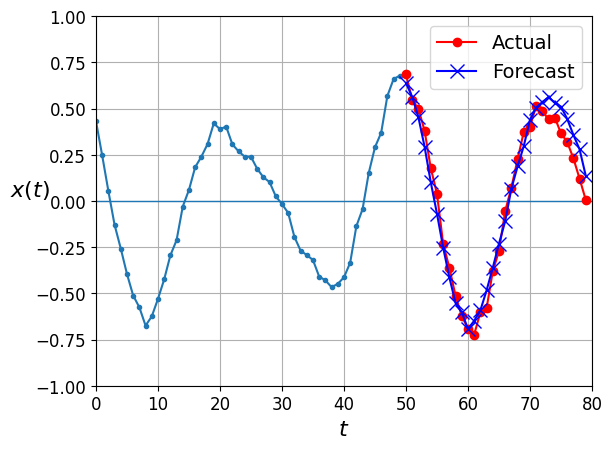

In [ ]:
# Plot time serie including prediction
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()